<a href="https://colab.research.google.com/github/Ma-rCh/ML-Basic/blob/main/homework_08/homework_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Линейная алгебра, математический анализ

100


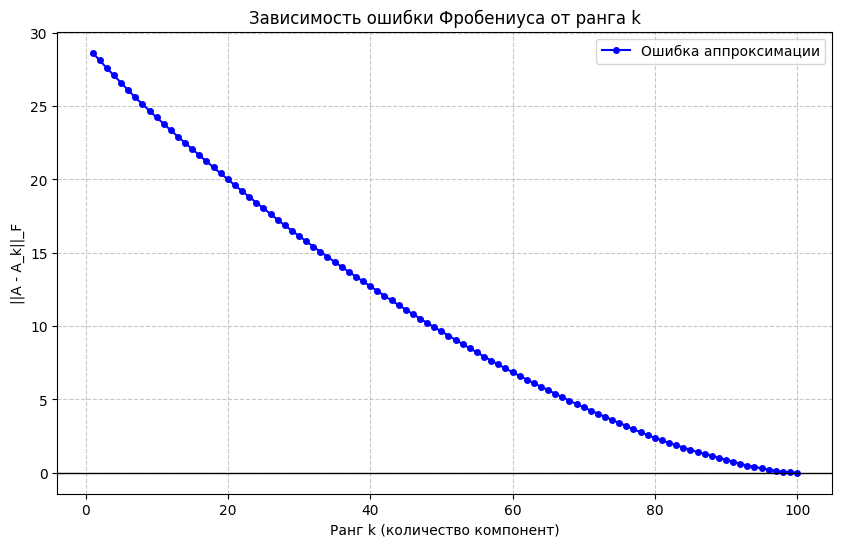

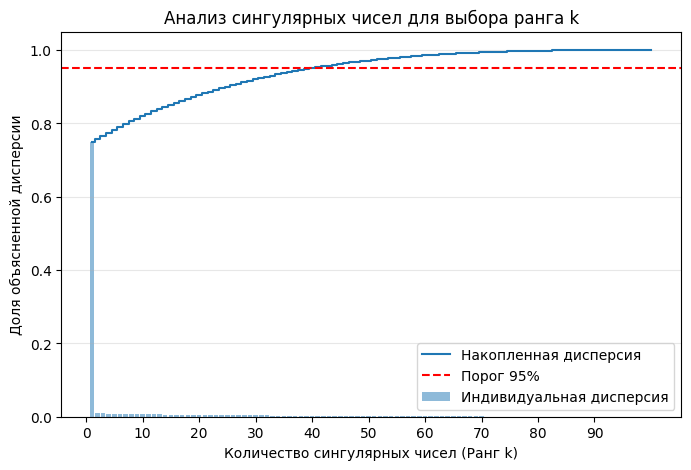

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

n = int(input())
# 1. Делаем SVD
A = np.random.rand(n, n)
U, s, Vh = np.linalg.svd(A)

# 2. Считаем долю объясненной дисперсии для каждого числа
exp_var = (s**2) / np.sum(s**2)

# 3. Считаем накопленную сумму (кумулятивную дисперсию)
cum_exp_var = np.cumsum(exp_var)

# 4. Вычисляем ошибки для каждого k от 1 до n
ranks = np.arange(1, n + 1)
errors = []

for k in ranks:
    # Аппроксимация ранга k
    A_k = U[:, :k] @ np.diag(s[:k]) @ Vh[:k, :]
    # Считаем норму Фробениуса разности
    err = np.linalg.norm(A - A_k, ord='fro')
    errors.append(err)

# 5. Строим график
plt.figure(figsize=(10, 6))
plt.plot(ranks, errors, 'b-o', markersize=4, label='Ошибка аппроксимации')
#plt.fill_between(ranks, errors, color='blue', alpha=0.1)

plt.title('Зависимость ошибки Фробениуса от ранга k')
plt.xlabel('Ранг k (количество компонент)')
plt.ylabel('||A - A_k||_F')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', lw=1)
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid', label='Накопленная дисперсия')
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, label='Индивидуальная дисперсия')

plt.ylabel('Доля объясненной дисперсии')
plt.xlabel('Количество сингулярных чисел (Ранг k)')
plt.title('Анализ сингулярных чисел для выбора ранга k')
plt.xticks(range(0, n, 10))
plt.axhline(y=0.95, color='r', linestyle='--', label='Порог 95%') # Линия 95% качества
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.show()
